# M5 HPO · Chronos-2 Fine-Tuned Ensemble · v6 (Per-Segment Full FT Param Tuning)

Extends v4 by making **all** fine-tuning hyperparameters per-segment instead of shared:

| Parameter | v4 | v6 |
|-----------|----|-----------|
| `context_length` | per-segment | per-segment |
| `ft_steps` | shared (one value for all segs) | **per-segment** |
| `ft_mode` | shared | **per-segment** |
| `ft_lr` | shared | **per-segment** |
| `ft_bs` | shared | **per-segment** |
| `cov_type` | shared | **per-segment** |
| `seg_columns` | shared | shared |

**Cache reuse**: `_make_seg_tag` is already per-segment and encodes all FT params including `cov_type`.
Any segment run in a previous study (v4 or earlier) with the same
`(scheme, seg, CL, ft_steps, ft_mode, ft_lr, ft_bs, cov_type)` is an instant cache hit —
no re-training, just a parquet read.

# 1 · Imports

In [1]:
import os
import sys
sys.path.append("/home/nmwamsojo/tsfm-explo/src/jobs/")

import gc
import json
import contextlib
import threading
from concurrent.futures import ThreadPoolExecutor, as_completed

import torch
import optuna
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from IPython.display import display

from m5_dataprep import M5DataPipeline
from m5_exploration import M5ExplorationSuite, DEFAULT_CHRONOS_CONFIG
from m5_evaluator import M5Evaluator

print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    for i in range(torch.cuda.device_count()):
        props = torch.cuda.get_device_properties(i)
        print(f"  GPU {i}: {torch.cuda.get_device_name(i)}  ({props.total_memory // 1024**3} GB)")

/home/nmwamsojo/tsfm-explo/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


CUDA available: True
  GPU 0: Quadro RTX 5000  (15 GB)
  GPU 1: Quadro RTX 5000  (15 GB)


In [2]:
# 4 threads per GPU worker × 2 workers = 8 of 20 CPUs for BLAS/data loading.
os.environ["OMP_NUM_THREADS"]        = "4"
os.environ["MKL_NUM_THREADS"]        = "4"
os.environ["OPENBLAS_NUM_THREADS"]   = "4"
os.environ["VECLIB_MAXIMUM_THREADS"] = "4"
os.environ["NUMEXPR_NUM_THREADS"]    = "4"
os.environ["CUDA_VISIBLE_DEVICES"]   = "0,1"

DEVICES = [f"cuda:{i}" for i in range(torch.cuda.device_count())] if torch.cuda.is_available() else ["cpu"]
N_GPUS  = len(DEVICES)
print(f"Active devices ({N_GPUS}): {DEVICES}")

if torch.cuda.is_available():
    for _d in DEVICES:
        torch.zeros(1, device=_d)
    torch.cuda.synchronize()
    print("CUDA contexts pre-initialized on all devices.")

Active devices (2): ['cuda:0', 'cuda:1']
CUDA contexts pre-initialized on all devices.


# 2 · Config
**Edit this cell only** to change experiment settings.

In [4]:
# ── Data ──────────────────────────────────────────────────────────────────────
DATA_PATH     = "/mnt/lab/datasets/M5/jointed_M5.parquet"
CALENDAR_PATH = "/mnt/lab/nmwamsojo/m5_data/calendar.csv"
ACTUALS_PATH  = "/mnt/lab/nmwamsojo/m5_data/sales_test_evaluation.csv"

DATA_TAG = "sales_only"

CUTOFF_DAY = (
    pd.to_datetime("2016-05-22") - pd.Timedelta(days=28)
).strftime("%Y-%m-%d")
print(f"Cutoff day : {CUTOFF_DAY}")
print(f"Data tag   : {DATA_TAG}")

# ── Context-length search space (per segment) ─────────────────────────────────
CL_CHOICES = [2**i for i in range(10)]   # [1, 2, 4, ..., 512]
CL_CHOICES = [1, 2, 4, 32, 64, 128, 256]
# ── Fine-tuning search space (per segment) ────────────────────────────────────
FT_STEPS_CHOICES = [0, 100, 200, 500, 1000, 1500, 2000, 3000]
FT_MODE_CHOICES  = ["lora", "full"]
FT_LR_CHOICES    = [1e-5, 5e-5, 1e-4, 5e-4, 1e-3, 5e-3, 1e-2]
FT_BATCH_CHOICES = [16, 32, 64, 128, 256]

BATCH_SIZE = 64
N_TRIALS   = 200

# ── Covariate search space (per segment) ─────────────────────────────────────
COVARIATE_OPTIONS = {
    "is_weekend":  ["is_friday", "is_saturday", "is_sunday"],
    #"event":       ["event_name_1", "event_type_1"],
    #"price":       ["sell_price"],
    #"snap":        ["snap_CA", "snap_TX", "snap_WI"],
    "is_weekend_event":  ["is_friday", "is_saturday", "is_sunday", "event_name_1", "event_type_1"],
    "is_weekend_price":  ["is_friday", "is_saturday", "is_sunday", "sell_price"],
    #"event_price": ["event_name_1", "event_type_1", "sell_price"],
    "is_weekend_snap":       ["is_friday", "is_saturday", "is_sunday", "snap_CA", "snap_TX", "snap_WI"],
    #"event_snap":            ["event_name_1", "event_type_1", "snap_CA", "snap_TX", "snap_WI"],
    #"price_snap":            ["sell_price", "snap_CA", "snap_TX", "snap_WI"],
    "is_weekend_event_snap": ["is_friday", "is_saturday", "is_sunday", "event_name_1", "event_type_1", "snap_CA", "snap_TX", "snap_WI"],
    "is_weekend_price_snap": ["is_friday", "is_saturday", "is_sunday", "sell_price", "snap_CA", "snap_TX", "snap_WI"],
    #"event_price_snap":      ["event_name_1", "event_type_1", "sell_price", "snap_CA", "snap_TX", "snap_WI"],
    "all": ["is_friday", "is_saturday", "is_sunday", "event_name_1", "event_type_1", "sell_price", "snap_CA", "snap_TX", "snap_WI"],
}
COV_CHOICES = list(COVARIATE_OPTIONS.keys())

# ── Optuna study persistence ──────────────────────────────────────────────────
OPTUNA_DB = "/mnt/lab/nmwamsojo/optuna_ft_ensemble_v7.db"

# Set True to delete the DB and start a completely fresh study.
# Required whenever any choice list (CL_CHOICES, FT_STEPS_CHOICES, etc.) is changed
# after the study has already been created — Optuna's RDB storage raises
# "CategoricalDistribution does not support dynamic value space" if a parameter
# is re-registered with a different set of choices.
FORCE_FRESH_STUDY = True   # ← set back to False once the DB is cleanly initialised

print(f"CL choices       : {CL_CHOICES}")
print(f"FT steps         : {FT_STEPS_CHOICES}")
print(f"FT modes         : {FT_MODE_CHOICES}")
print(f"FT lr            : {FT_LR_CHOICES}")
print(f"FT batch         : {FT_BATCH_CHOICES}")
print(f"Cov options      : {COV_CHOICES}")
print(f"Inference batch  : {BATCH_SIZE}")
print(f"Trials budget    : {N_TRIALS}")
print(f"Optuna DB        : {OPTUNA_DB}")
print(f"Force fresh study: {FORCE_FRESH_STUDY}")

WRAPPER = {
    "eval_metric":          "RMSSE",
    "enable_ensemble":      False,
    "skip_model_selection": True,
    "verbosity":            1,
}

CFG_CHRONOS_BASE = {
    **DEFAULT_CHRONOS_CONFIG,
    "use_static": False,
}

Cutoff day : 2016-04-24
Data tag   : sales_only
CL choices       : [1, 2, 4, 32, 64, 128, 256]
FT steps         : [0, 100, 200, 500, 1000, 1500, 2000, 3000]
FT modes         : ['lora', 'full']
FT lr            : [1e-05, 5e-05, 0.0001, 0.0005, 0.001, 0.005, 0.01]
FT batch         : [16, 32, 64, 128, 256]
Cov options      : ['is_weekend', 'is_weekend_event', 'is_weekend_price', 'is_weekend_snap', 'is_weekend_event_snap', 'is_weekend_price_snap', 'all']
Inference batch  : 64
Trials budget    : 200
Optuna DB        : /mnt/lab/nmwamsojo/optuna_ft_ensemble_v7.db
Force fresh study: True


# 3 · Data

In [5]:
pipeline = M5DataPipeline(config={"tag": DATA_TAG})
hist_df, hist_df_trimmed, future_df, static_df, weights_scales = (
    pipeline.get_prepared_data(DATA_PATH, CUTOFF_DAY, level=12, force_reprepare=False)
)

print(f"\nhist_df         : {hist_df.shape}  cols: {list(hist_df.columns)}")
print(f"hist_df_trimmed : {hist_df_trimmed.shape}")
print(f"future_df       : {future_df.shape}")
print(f"static_df       : {static_df.shape}")
print(f"weights_scales  : {weights_scales.shape}  levels: {sorted(weights_scales['level'].unique())}")

del pipeline
gc.collect()

--- Cache Hit: Data found in /mnt/lab/nmwamsojo/prepared_data/sales_only/level_12/20160424 ---

hist_df         : (58327370, 21)  cols: ['id', 'date', 'sales_quantity', 'wm_yr_wk', 'wday', 'month', 'year', 'event_name_1', 'event_type_1', 'snap_CA', 'snap_TX', 'snap_WI', 'sell_price', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id', 'is_friday', 'is_saturday', 'is_sunday']
hist_df_trimmed : (45942500, 21)
future_df       : (853720, 20)
static_df       : (30490, 6)
weights_scales  : (42840, 7)  levels: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12)]


20

In [6]:
def _wide_to_long(gt_wide: pd.DataFrame, calendar_path: str) -> pd.DataFrame:
    if "id" not in gt_wide.columns:
        gt_wide["id"] = gt_wide["item_id"] + "_" + gt_wide["store_id"] + "_evaluation"
    day_cols = [c for c in gt_wide.columns if c.startswith("d_")]
    long = gt_wide.melt(id_vars=["id"], value_vars=day_cols,
                        var_name="d", value_name="sales_quantity")
    cal = pd.read_csv(calendar_path, usecols=["d", "date"])
    cal["date"] = pd.to_datetime(cal["date"])
    long = long.merge(cal, on="d", how="left").drop(columns=["d"])
    long["id"] = long["id"].str.replace("_evaluation", "", regex=False)
    return long[["id", "date", "sales_quantity"]]


if CUTOFF_DAY == "2016-05-22":
    _eval_raw = pd.read_csv(ACTUALS_PATH)
    df_actual = _wide_to_long(_eval_raw, CALENDAR_PATH)
    del _eval_raw
else:
    df_actual = (
        pd.read_parquet(DATA_PATH, columns=["id", "date", "sold"])
        .rename(columns={"sold": "sales_quantity"})
    )
    df_actual["id"] = (
        df_actual["id"].astype(str)
        .str.replace("_evaluation", "", regex=False)
        .str.replace("_validation",  "", regex=False)
    )

print(f"Actuals : {df_actual.shape}  |  "
      f"{df_actual['date'].min().date()} \u2192 {df_actual['date'].max().date()}")

Actuals : (59181090, 3)  |  2011-01-29 → 2016-05-22


# 4 · Evaluator & Suite
Initialised **once** — reused across all trials.

In [7]:
evaluator = M5Evaluator(
    raw_train_df     = hist_df,
    trimmed_train_df = hist_df_trimmed,
    static_df        = static_df,
    weights_df       = weights_scales,
    target_col       = "sales_quantity",
    price_col        = "sell_price",
)

suites = {
    device: M5ExplorationSuite(
        horizon  = 28,
        ag_path  = "/mnt/lab/nmwamsojo/autogluon_models/explorations",
        base_dir = "/mnt/lab/nmwamsojo/prepared_data",
    )
    for device in DEVICES
}
print(f"Evaluator ready. Suites: {list(suites.keys())}")

  [CPU] CuPy not available — scale computation on 18 CPU cores.
  Building hierarchy scales and weights …
Evaluator ready. Suites: ['cuda:0', 'cuda:1']


# 5 · Segment ID Map

In [8]:
quantile_labels = ["Low", "Medium-Low", "Medium-High", "High"]

weights_scales["weight_segs"] = pd.qcut(
    weights_scales["weight"],
    q=4,
    labels=quantile_labels,
)

In [9]:
SEG_NAMES_MAP = {
    "weight_segs":     ["Low", "Medium-Low", "Medium-High", "High"],
    #"smoothness_segs": ["Smooth", "Erratic", "Intermittent", "Lumpy"],
}
UNDEFINED_IN = {
    "weight_segs":     "Low",
    "smoothness_segs": "Lumpy",
}

SEG_ID_MAPS: dict[str, dict[str, list]] = {}

for _seg_cols, _seg_names in SEG_NAMES_MAP.items():
    _undef_in = UNDEFINED_IN[_seg_cols]
    if _seg_cols in hist_df_trimmed.columns:
        _src = hist_df_trimmed[["id", _seg_cols]].drop_duplicates()
    else:
        _src = (
            weights_scales[weights_scales["level"] == 12][["id", _seg_cols]]
            .dropna(subset=[_seg_cols])
        )
    _id_map = {seg: _src[_src[_seg_cols] == seg]["id"].tolist() for seg in _seg_names}
    _id_map[_undef_in].extend(_src[_src[_seg_cols] == "Undefined"]["id"].tolist())
    SEG_ID_MAPS[_seg_cols] = _id_map
    del _src

for _seg_cols, _id_map in SEG_ID_MAPS.items():
    _total  = sum(len(v) for v in _id_map.values())
    _scheme = _seg_cols.replace("_segs", "")
    print(f"\n[{_scheme}]")
    for seg, ids in _id_map.items():
        print(f"  {seg:>14}: {len(ids):>6,}  ({100*len(ids)/_total:.1f}%)")
    print(f"  {'TOTAL':>14}: {_total:>6,}")

SEG_ID_SETS = {
    seg_cols: {seg: set(ids) for seg, ids in id_map.items()}
    for seg_cols, id_map in SEG_ID_MAPS.items()
}


[weight]
             Low:  9,835  (32.3%)
      Medium-Low:  9,349  (30.7%)
     Medium-High:  7,688  (25.2%)
            High:  3,618  (11.9%)
           TOTAL: 30,490


# 6 · Optuna HPO

Each trial samples:
- **`seg_columns`** — segmentation scheme (`weight_segs` or `smoothness_segs`)
- Per segment (scheme-prefixed): `CL`, `ft_steps`, `ft_mode`\*, `ft_lr`\*, `ft_bs`\*, `cov_type`
  (\*skipped when `ft_steps=0` for that segment)

**Cache key** = `(seg_scheme, cl, ft_steps, ft_mode, ft_lr, ft_bs, cov_type)` — identical
to v4/v5-earlier, so all previously computed segment forecasts are instant cache hits.

In [10]:
# Serializes model loads across threads — Accelerate's dispatch_model is not thread-safe.
# Cache-hit runs (parquet read only) bypass this lock entirely.
_model_load_lock = threading.Lock()


def _run_one_segment(
    seg_name:   str,
    seg_ids:    set,
    seg_scheme: str,
    cl:         int,
    device:     str,
    ft_steps:   int,
    ft_mode:    str,
    ft_lr:      float,
    ft_bs:      int,
    cov_type:   str,
) -> tuple[str, pd.DataFrame]:
    """Fit/infer one segment on the assigned GPU. Called from a worker thread."""
    device_idx = int(device.split(":")[-1]) if ":" in device else 0
    torch.cuda.set_device(device_idx)

    seg_tag = _make_seg_tag(seg_scheme, cl, ft_steps, ft_mode, ft_lr, ft_bs, cov_type)



    _forecast_path = os.path.join(
        suites[device].base_dir, DATA_TAG, "level_12",
        CUTOFF_DAY.replace("-", ""), "models", seg_tag, "forecasts.parquet",
    )
    _lock_ctx = contextlib.nullcontext() if os.path.exists(_forecast_path) else _model_load_lock

    cfg = {
        **CFG_CHRONOS_BASE,
        "context_length":       cl,
        "fine_tune_steps":      ft_steps,
        "fine_tune_mode":       ft_mode,
        "fine_tune_lr":         ft_lr,
        "fine_tune_batch_size": ft_bs,
        "batch_size":           BATCH_SIZE,
        "known_cov_cols":       COVARIATE_OPTIONS[cov_type],
        "device":               device,
    }

    with _lock_ctx:
        fcst = suites[device].run(
            hist_df      = hist_df_trimmed,
            future_df    = future_df,
            static_df    = static_df,
            model        = "Chronos2",
            exp_config   = cfg,
            exp_tag      = seg_tag,
            data_tag     = DATA_TAG,
            cutoff_day   = CUTOFF_DAY,
            wrapper_dict = WRAPPER,
            force_run    = False,
        )

    torch.cuda.empty_cache()
    filtered = fcst[fcst["id"].isin(seg_ids)].copy()
    del fcst
    gc.collect()
    return seg_name, filtered


print("_run_one_segment helper ready.")

_run_one_segment helper ready.


In [11]:
# Only seg_columns is shared — all other params are per-segment
SHARED_PARAMS = ["seg_columns"]


def _make_seg_tag(seg_scheme: str, cl: int,
                  ft_steps: int, ft_mode: str, ft_lr: float,
                  ft_bs: int, cov_type: str) -> str:
    if ft_steps == 0:
        return f"hpo_zs_{seg_scheme}_cl{cl}_{cov_type}"
    lr_str = f"{ft_lr:.0e}".replace("-0", "-")
    return (
        f"hpo_ft_{seg_scheme}_cl{cl}"
        f"_steps{ft_steps}_{ft_mode}_lr{lr_str}_bs{ft_bs}_{cov_type}"
    )


def _seg_key(seg_scheme: str, seg: str) -> str:
    """Canonical Optuna param prefix for a (scheme, segment) pair."""
    return f"{seg_scheme}_{seg.lower().replace('-', '_').replace(' ', '_')}"


def objective(trial: optuna.Trial) -> float:
    # ── 1. Sample segmentation scheme ────────────────────────────────────────
    seg_columns     = trial.suggest_categorical("seg_columns", list(SEG_NAMES_MAP.keys()))
    seg_scheme      = seg_columns.replace("_segs", "")
    trial_seg_names = SEG_NAMES_MAP[seg_columns]

    # ── 2. Sample ALL params per segment (scheme-conditional key prefix) ──────
    # ft_mode/lr/bs are ALWAYS sampled (never conditional on ft_steps) so that
    # Optuna's RDB storage sees a static parameter space across all trials —
    # conditional sampling causes "dynamic value space" errors when the study
    # is resumed and a parameter appears for the first time after prior trials
    # registered it with a different set of choices.
    seg_params: dict[str, dict] = {}
    for seg in trial_seg_names:
        sk = _seg_key(seg_scheme, seg)

        cl       = trial.suggest_categorical(f"CL_{sk}",       CL_CHOICES)
        ft_steps = trial.suggest_categorical(f"ft_steps_{sk}", FT_STEPS_CHOICES)
        ft_mode  = trial.suggest_categorical(f"ft_mode_{sk}",  FT_MODE_CHOICES)
        ft_lr    = trial.suggest_categorical(f"ft_lr_{sk}",    FT_LR_CHOICES)
        ft_bs    = trial.suggest_categorical(f"ft_bs_{sk}",    FT_BATCH_CHOICES)
        cov_type = trial.suggest_categorical(f"cov_type_{sk}", COV_CHOICES)

        seg_params[seg] = {
            "cl":       cl,
            "ft_steps": ft_steps,
            # ft_mode/lr/bs are sampled unconditionally but only USED when ft_steps > 0
            "ft_mode":  ft_mode if ft_steps > 0 else "lora",
            "ft_lr":    ft_lr   if ft_steps > 0 else 1e-4,
            "ft_bs":    ft_bs   if ft_steps > 0 else 128,
            "cov_type": cov_type,
        }

    # ── Log trial summary ─────────────────────────────────────────────────────
    print(f"\n[Trial {trial.number}] scheme={seg_scheme}")
    for seg, p in seg_params.items():
        ft_str = (
            f"steps={p['ft_steps']} mode={p['ft_mode']} lr={p['ft_lr']:.0e} bs={p['ft_bs']}"
            if p["ft_steps"] > 0 else "steps=0 (ZS)"
        )
        print(f"  {seg:>14}: CL={p['cl']:>3}  {ft_str}  cov={p['cov_type']}")

    # ── Flush TSDF caches on the module-level suites before each trial ────────
    # suites is the module-level dict from evaluator_setup — the same object
    # that _run_one_segment uses. Clearing it here releases the previous trial's
    # TimeSeriesDataFrame (~1-3 GB per GPU) before new ones are built.
    for _s in suites.values():
        _s._cached_tsdf.clear()
        _s._cached_future.clear()
    gc.collect(2)
    for _d in DEVICES:
        with torch.cuda.device(_d):
            torch.cuda.empty_cache()

    # ── 3. GPU assignment & parallel execution ────────────────────────────────
    seg_assignments = [
        (
            seg,
            seg_params[seg]["cl"],
            SEG_ID_SETS[seg_columns][seg],
            seg_scheme,
            DEVICES[i % N_GPUS],
            seg_params[seg]["ft_steps"],
            seg_params[seg]["ft_mode"],
            seg_params[seg]["ft_lr"],
            seg_params[seg]["ft_bs"],
            seg_params[seg]["cov_type"],
        )
        for i, seg in enumerate(trial_seg_names)
    ]

    results: dict[str, pd.DataFrame] = {}
    try:
        with ThreadPoolExecutor(max_workers=N_GPUS) as executor:
            future_map = {
                executor.submit(
                    _run_one_segment,
                    seg, ids, scheme, cl, device,
                    ft_steps, ft_mode, ft_lr, ft_bs, cov_type,
                ): seg
                for seg, cl, ids, scheme, device,
                    ft_steps, ft_mode, ft_lr, ft_bs, cov_type in seg_assignments
            }
            for fut in as_completed(future_map):
                name, fcst = fut.result()
                results[name] = fcst
            del future_map

        # ── 4. Merge → evaluate ───────────────────────────────────────────────
        ensemble_fcst = pd.concat(list(results.values()), ignore_index=True)
        results.clear()

        metrics = evaluator.evaluate_all(ensemble_fcst, df_actual)
        del ensemble_fcst
        wrmsse = float(metrics["WRMSSE"])
        del metrics

        # ── 5. Log user attrs ─────────────────────────────────────────────────
        trial.set_user_attr("seg_columns", seg_columns)
        trial.set_user_attr("WRMSSE", wrmsse)
        for seg, p in seg_params.items():
            sk = _seg_key(seg_scheme, seg)
            for param_name, val in p.items():
                trial.set_user_attr(f"{param_name}_{sk}", val)

        print(f"[Trial {trial.number}] WRMSSE = {wrmsse:.4f}")
        return wrmsse

    except Exception as e:
        print(f"[Trial {trial.number}] failed: {e}")
        results.clear()
        return float("inf")

    finally:
        # Runs on both success and failure. Full generational GC collects cyclic
        # refs in TSDF / Lightning trainer objects that gen-0 GC misses.
        gc.collect(2)
        for _d in DEVICES:
            with torch.cuda.device(_d):
                torch.cuda.empty_cache()
        # Return freed glibc heap pages to the OS to prevent monotonic RSS growth.
        try:
            import ctypes
            ctypes.CDLL("libc.so.6").malloc_trim(0)
        except Exception:
            pass


In [ ]:
optuna.logging.set_verbosity(optuna.logging.WARNING)

if FORCE_FRESH_STUDY and os.path.exists(OPTUNA_DB):
    os.remove(OPTUNA_DB)
    print(f"Deleted stale DB: {OPTUNA_DB}")

storage = f"sqlite:///{OPTUNA_DB}"
study = optuna.create_study(
    direction      = "minimize",
    sampler        = optuna.samplers.TPESampler(seed=42),
    study_name     = "chronos_ft_ensemble_v6",
    storage        = storage,
    load_if_exists = True,
)

_state_counts = {s.name: 0 for s in optuna.trial.TrialState}
for _t in study.trials:
    _state_counts[_t.state.name] += 1
print(f"Study loaded — " + "  |  ".join(f"{v} {k.lower()}" for k, v in _state_counts.items() if v))

_df = study.trials_dataframe(attrs=("number", "value", "params", "user_attrs"))
# trials_dataframe returns no "value" column when the study has zero completed trials
if not _df.empty and "value" in _df.columns:
    _df = _df[_df["value"].notna()].sort_values("value").reset_index(drop=True)
    _df.rename(columns={"value": "WRMSSE"}, inplace=True)
else:
    _df = pd.DataFrame()
completed = len(_df)

if completed > 0:
    _per_seg_cols = sorted(
        c for c in _df.columns
        if any(c.startswith(f"params_{p}_") for p in ["CL", "ft_steps", "ft_mode", "ft_lr", "ft_bs", "cov_type"])
    )
    _fixed = [c for c in ["params_seg_columns"] if c in _df.columns]
    _show = ["number", "WRMSSE"] + _fixed + _per_seg_cols
    display(
        _df[_show].head(20).style
        .format({"WRMSSE": "{:.4f}"})
        .background_gradient(subset=["WRMSSE"], cmap="RdYlGn_r")
        .set_caption(f"Stored trials ({completed} with values) — top 20 by WRMSSE ↓")
    )
    print(_df[_show].head(20).to_string(index=False))
    print(f"\nBest  WRMSSE = {_df['WRMSSE'].min():.4f}  (trial #{int(_df.iloc[0]['number'])})")
    print(f"Worst WRMSSE = {_df['WRMSSE'].max():.4f}")
else:
    print("No completed trials found in the study yet.")
del _df
print("─" * 70)

study.optimize(objective, n_trials=N_TRIALS, n_jobs=1, gc_after_trial=True)

print(f"\nBest WRMSSE : {study.best_value:.4f}")
print(f"Best params : {study.best_params}")

Deleted stale DB: /mnt/lab/nmwamsojo/optuna_ft_ensemble_v7.db
Study loaded — 
No completed trials found in the study yet.
──────────────────────────────────────────────────────────────────────

[Trial 0] scheme=weight
             Low: CL=  2  steps=1000 mode=full lr=5e-04 bs=32  cov=is_weekend_price_snap
      Medium-Low: CL=  4  steps=3000 mode=full lr=1e-04 bs=64  cov=is_weekend_event_snap
     Medium-High: CL=  2  steps=100 mode=full lr=5e-03 bs=16  cov=is_weekend_snap
            High: CL= 64  steps=2000 mode=full lr=1e-04 bs=64  cov=is_weekend_price
[hpo_ft_weight_cl4_steps3000_full_lr1e-4_bs64_is_weekend_event_snap] Forecasts not found at /mnt/lab/nmwamsojo/prepared_data/sales_only/level_12/20160424/models/hpo_ft_weight_cl4_steps3000_full_lr1e-4_bs64_is_weekend_event_snap/forecasts.parquet…
[hpo_ft_weight_cl4_steps3000_full_lr1e-4_bs64_is_weekend_event_snap] Running Chronos2 experiment…
  known covariates : ['is_friday', 'is_saturday', 'is_sunday', 'event_name_1', 'event_type_1'

# 7 · Results

In [ ]:
df_trials = study.trials_dataframe(attrs=("number", "value", "params", "user_attrs"))
# trials_dataframe returns no "value" column when the study has zero completed trials
if not df_trials.empty and "value" in df_trials.columns:
    df_trials = df_trials[df_trials["value"].notna()].sort_values("value").reset_index(drop=True)
    df_trials.rename(columns={"value": "WRMSSE"}, inplace=True)
else:
    df_trials = pd.DataFrame(columns=["number", "WRMSSE"])

if df_trials.empty:
    print("No completed trials to display.")
else:
    # All per-segment columns (CL, FT params, cov_type), grouped by parameter for readability
    per_seg_cols = sorted(
        c for c in df_trials.columns
        if any(c.startswith(f"params_{p}_") for p in ["CL", "ft_steps", "ft_mode", "ft_lr", "ft_bs", "cov_type"])
    )
    fixed_cols = [c for c in ["params_seg_columns"] if c in df_trials.columns]

    display(
        df_trials[["number", "WRMSSE"] + fixed_cols + per_seg_cols]
        .head(20)
        .style
        .format({"WRMSSE": "{:.4f}"})
        .background_gradient(subset=["WRMSSE"], cmap="RdYlGn_r")
        .set_caption("Top-20 trials by ensemble WRMSSE (lower is better)")
    )

    print(f"\nBest  WRMSSE = {df_trials['WRMSSE'].min():.4f}  "
          f"(trial #{int(df_trials.iloc[0]['number'])})")
    print(f"Worst WRMSSE = {df_trials['WRMSSE'].max():.4f}")

    # ── Summary by scheme ─────────────────────────────────────────────────────
    if "params_seg_columns" in df_trials.columns:
        print(f"\nMean WRMSSE by seg_columns:")
        print(
            df_trials.groupby("params_seg_columns")["WRMSSE"]
            .agg(["mean", "min", "count"])
            .sort_values("mean")
            .to_string()
        )

,number,WRMSSE,params_seg_columns,params_CL_smoothness_erratic,params_CL_smoothness_intermittent,params_CL_smoothness_lumpy,params_CL_smoothness_smooth,params_CL_weight_high,params_CL_weight_low,params_CL_weight_medium_high,params_CL_weight_medium_low,params_cov_type_smoothness_erratic,params_cov_type_smoothness_intermittent,params_cov_type_smoothness_lumpy,params_cov_type_smoothness_smooth,params_cov_type_weight_high,params_cov_type_weight_low,params_cov_type_weight_medium_high,params_cov_type_weight_medium_low,params_ft_bs_smoothness_erratic,params_ft_bs_smoothness_intermittent,params_ft_bs_smoothness_lumpy,params_ft_bs_smoothness_smooth,params_ft_bs_weight_high,params_ft_bs_weight_low,params_ft_bs_weight_medium_high,params_ft_bs_weight_medium_low,params_ft_lr_smoothness_erratic,params_ft_lr_smoothness_intermittent,params_ft_lr_smoothness_lumpy,params_ft_lr_smoothness_smooth,params_ft_lr_weight_high,params_ft_lr_weight_low,params_ft_lr_weight_medium_high,params_ft_lr_weight_medium_low,params_ft_mode_smoothness_erratic,params_ft_mode_smoothness_intermittent,params_ft_mode_smoothness_lumpy,params_ft_mode_smoothness_smooth,params_ft_mode_weight_high,params_ft_mode_weight_low,params_ft_mode_weight_medium_high,params_ft_mode_weight_medium_low,params_ft_steps_smoothness_erratic,params_ft_steps_smoothness_intermittent,params_ft_steps_smoothness_lumpy,params_ft_steps_smoothness_smooth,params_ft_steps_weight_high,params_ft_steps_weight_low,params_ft_steps_weight_medium_high,params_ft_steps_weight_medium_low
0,0,inf,smoothness_segs,8.000000,4.000000,4.000000,512.000000,nan,nan,nan,nan,is_weekend_event_snap,is_weekend_price_snap,is_weekend_event_snap,event,nan,nan,nan,nan,128.000000,128.000000,64.000000,64.000000,nan,nan,nan,nan,0.000100,0.000010,0.000010,0.000500,nan,nan,nan,nan,lora,lora,full,lora,nan,nan,nan,nan,1500.000000,200.000000,3000.000000,0.000000,nan,nan,nan,nan
1,1,inf,weight_segs,nan,nan,nan,nan,32.000000,256.000000,64.000000,2.000000,nan,nan,nan,nan,event_snap,is_weekend_price_snap,is_weekend,event,nan,nan,nan,nan,32.000000,256.000000,256.000000,32.000000,nan,nan,nan,nan,0.010000,0.000500,0.000100,0.000010,nan,nan,nan,nan,lora,full,lora,lora,nan,nan,nan,nan,3000.000000,500.000000,1500.000000,200.000000
2,2,inf,weight_segs,nan,nan,nan,nan,128.000000,1.000000,256.000000,2.000000,nan,nan,nan,nan,is_weekend,is_weekend_price_snap,event_price_snap,is_weekend_event,nan,nan,nan,nan,256.000000,128.000000,128.000000,256.000000,nan,nan,nan,nan,0.000050,0.001000,0.000100,0.010000,nan,nan,nan,nan,full,full,full,full,nan,nan,nan,nan,3000.000000,3000.000000,1500.000000,2000.000000
3,3,inf,smoothness_segs,2.000000,128.000000,2.000000,64.000000,nan,nan,nan,nan,is_weekend_snap,event_price,snap,price,nan,nan,nan,nan,256.000000,64.000000,32.000000,32.000000,nan,nan,nan,nan,0.000100,0.000500,0.000100,0.000010,nan,nan,nan,nan,lora,full,full,full,nan,nan,nan,nan,2000.000000,0.000000,200.000000,0.000000,nan,nan,nan,nan
4,4,inf,weight_segs,nan,nan,nan,nan,16.000000,32.000000,32.000000,4.000000,nan,nan,nan,nan,event,event_price,price,is_weekend_event,nan,nan,nan,nan,32.000000,64.000000,32.000000,256.000000,nan,nan,nan,nan,0.010000,0.000050,0.000500,0.000050,nan,nan,nan,nan,full,lora,full,lora,nan,nan,nan,nan,100.000000,1500.000000,2000.000000,1000.000000
5,5,inf,weight_segs,nan,nan,nan,nan,128.000000,32.000000,512.000000,4.000000,nan,nan,nan,nan,is_weekend_event_snap,is_weekend_event_snap,is_weekend_price_snap,is_weekend_event_snap,nan,nan,nan,nan,32.000000,256.000000,32.000000,32.000000,nan,nan,nan,nan,0.000050,0.000010,0.000050,0.001000,nan,nan,nan,nan,lora,full,lora,full,nan,nan,nan,nan,1000.000000,0.000000,0.000000,1000.000000
6,6,inf,weight_segs,nan,nan,nan,nan,512.000000,128.000000,2.000000,64.000000,nan,nan,nan,nan,is_weekend_price_snap,is_weekend_price_snap,all,event,nan,nan,nan,nan,256.000000,32.000000,128.000000,32.000000,nan,nan,nan,nan,0.000050,0.010000,0.005000,0.000050,nan,nan,nan,nan,full,full,full,lora,nan,nan,nan,nan,100.000000,0


Best  WRMSSE = inf  (trial #0)
Worst WRMSSE = inf

Mean WRMSSE by seg_columns:
                    mean  min  count
params_seg_columns                  
smoothness_segs      inf  inf     33
weight_segs          inf  inf     67


In [ ]:
# ── Per-segment param summaries ───────────────────────────────────────────────
# For each scheme × segment × parameter, show mean/min WRMSSE by parameter value.
for seg_cols, seg_names_list in SEG_NAMES_MAP.items():
    scheme = seg_cols.replace("_segs", "")
    scheme_col = "params_seg_columns"

    if scheme_col in df_trials.columns:
        sub = df_trials[df_trials[scheme_col] == seg_cols]
    else:
        sub = df_trials

    if sub.empty:
        continue

    print(f"\n{'='*60}")
    print(f"Scheme: {scheme}  ({len(sub)} trials)")
    print(f"{'='*60}")

    for seg in seg_names_list:
        sk = _seg_key(scheme, seg)
        print(f"\n  [{seg}]")
        for param in ["CL", "ft_steps", "ft_mode", "ft_lr", "ft_bs", "cov_type"]:
            col = f"params_{param}_{sk}"
            if col not in sub.columns:
                continue
            summary = (
                sub.groupby(col)["WRMSSE"]
                .agg(["mean", "min", "count"])
                .sort_values("mean")
            )
            print(f"    {param}:")
            print(summary.to_string(float_format="{:.4f}".format))


Scheme: weight  (67 trials)

  [Low]
    CL:
                      mean  min  count
params_CL_weight_low                  
1.0                    inf  inf      9
2.0                    inf  inf      9
4.0                    inf  inf      4
8.0                    inf  inf      4
16.0                   inf  inf      4
32.0                   inf  inf     11
64.0                   inf  inf      6
128.0                  inf  inf      7
256.0                  inf  inf      9
512.0                  inf  inf      4
    ft_steps:
                            mean  min  count
params_ft_steps_weight_low                  
0.0                          inf  inf     12
100.0                        inf  inf      4
200.0                        inf  inf      4
500.0                        inf  inf     10
1000.0                       inf  inf      7
1500.0                       inf  inf     13
2000.0                       inf  inf      4
3000.0                       inf  inf     13
    ft_mode:
         

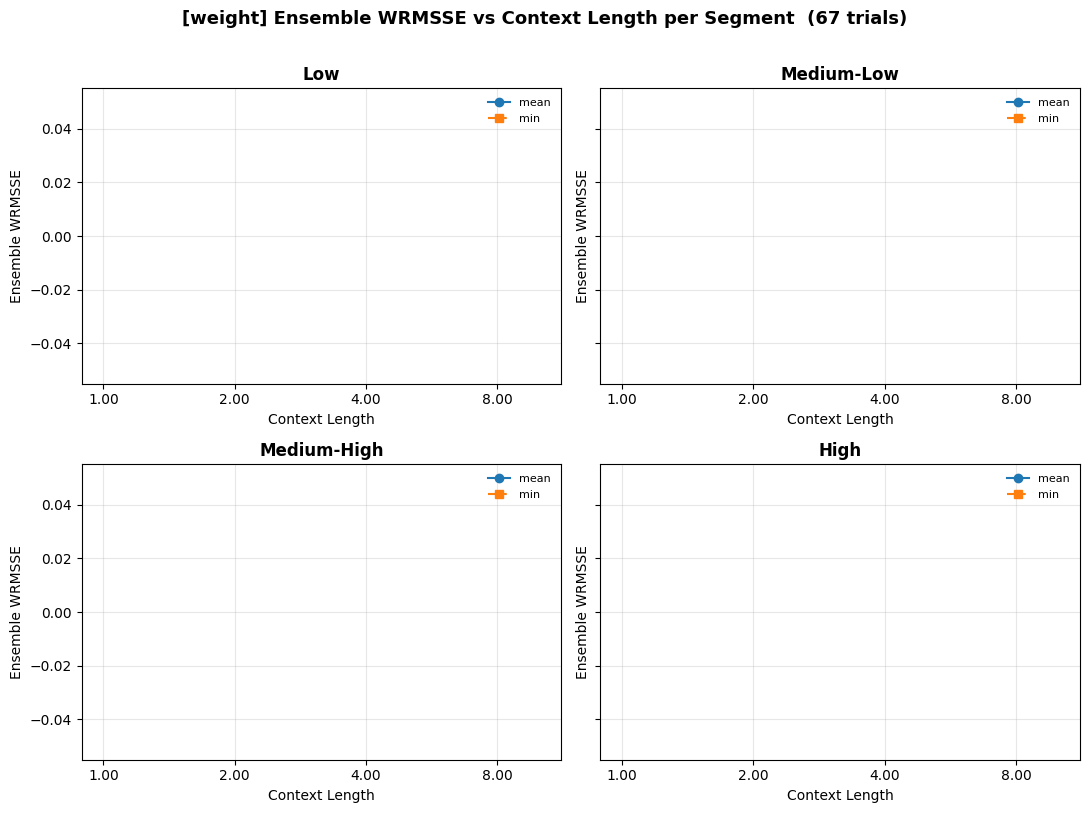

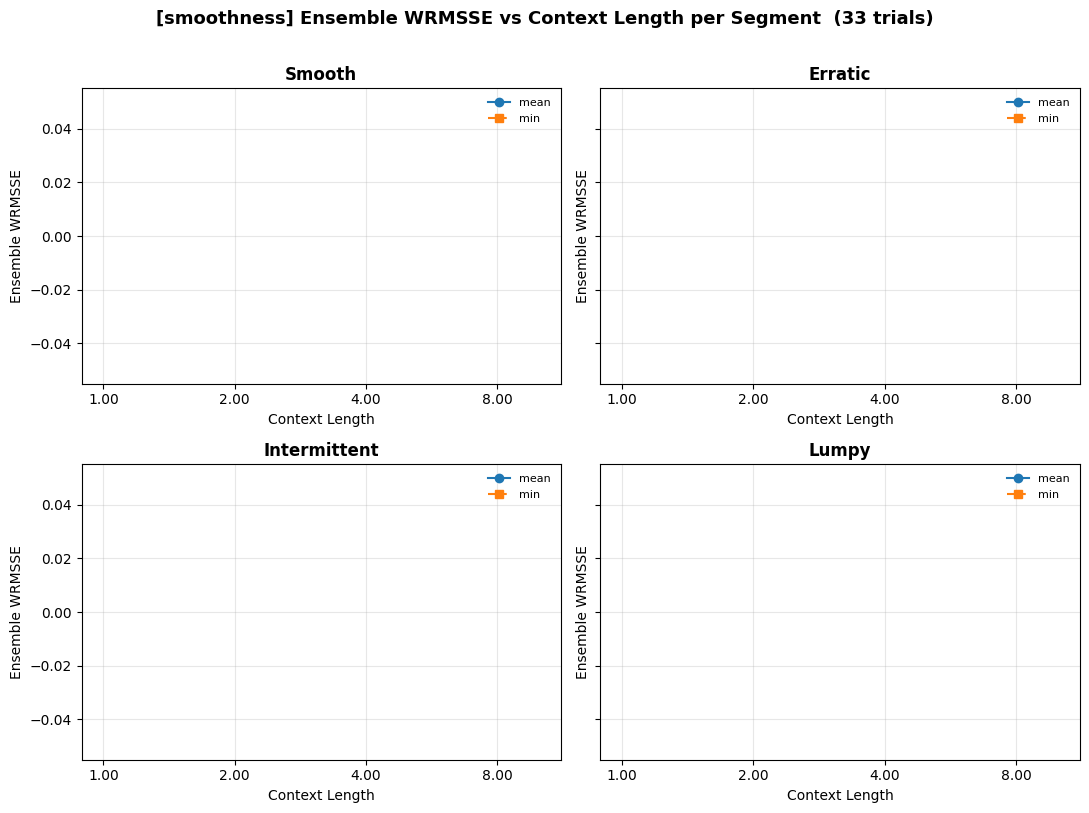

In [ ]:
# ── CL vs WRMSSE — one subplot per segment, split by scheme ──────────────────
scheme_col = "params_seg_columns"
has_scheme = scheme_col in df_trials.columns

for seg_cols, seg_names_list in SEG_NAMES_MAP.items():
    scheme = seg_cols.replace("_segs", "")

    if has_scheme:
        sub = df_trials[df_trials[scheme_col] == seg_cols]
    else:
        sub = df_trials

    if sub.empty:
        continue

    n_segs = len(seg_names_list)
    ncols  = min(n_segs, 2)
    nrows  = (n_segs + ncols - 1) // ncols

    fig, axes = plt.subplots(nrows, ncols, figsize=(11, 4 * nrows), sharey=True)
    axes = axes.flatten() if n_segs > 1 else [axes]

    for ax, seg in zip(axes, seg_names_list):
        sk      = _seg_key(scheme, seg)
        cl_key  = f"params_CL_{sk}"
        if cl_key not in sub.columns:
            ax.set_visible(False)
            continue
        grouped = sub.groupby(cl_key)["WRMSSE"].agg(["mean", "min"]).reset_index()
        ax.plot(grouped[cl_key], grouped["mean"], marker="o", label="mean")
        ax.plot(grouped[cl_key], grouped["min"],  marker="s", linestyle="--", label="min")
        ax.set_xscale("log", base=2)
        ax.set_title(seg, fontweight="bold")
        ax.set_xlabel("Context Length")
        ax.set_ylabel("Ensemble WRMSSE")
        ax.xaxis.set_major_formatter(mticker.ScalarFormatter())
        ax.legend(frameon=False, fontsize=8)
        ax.grid(True, alpha=0.3)

    for ax in axes[n_segs:]:
        ax.set_visible(False)

    fig.suptitle(
        f"[{scheme}] Ensemble WRMSSE vs Context Length per Segment  "
        f"({len(sub)} trials)",
        fontsize=13, fontweight="bold", y=1.01,
    )
    fig.tight_layout()
    plt.show()

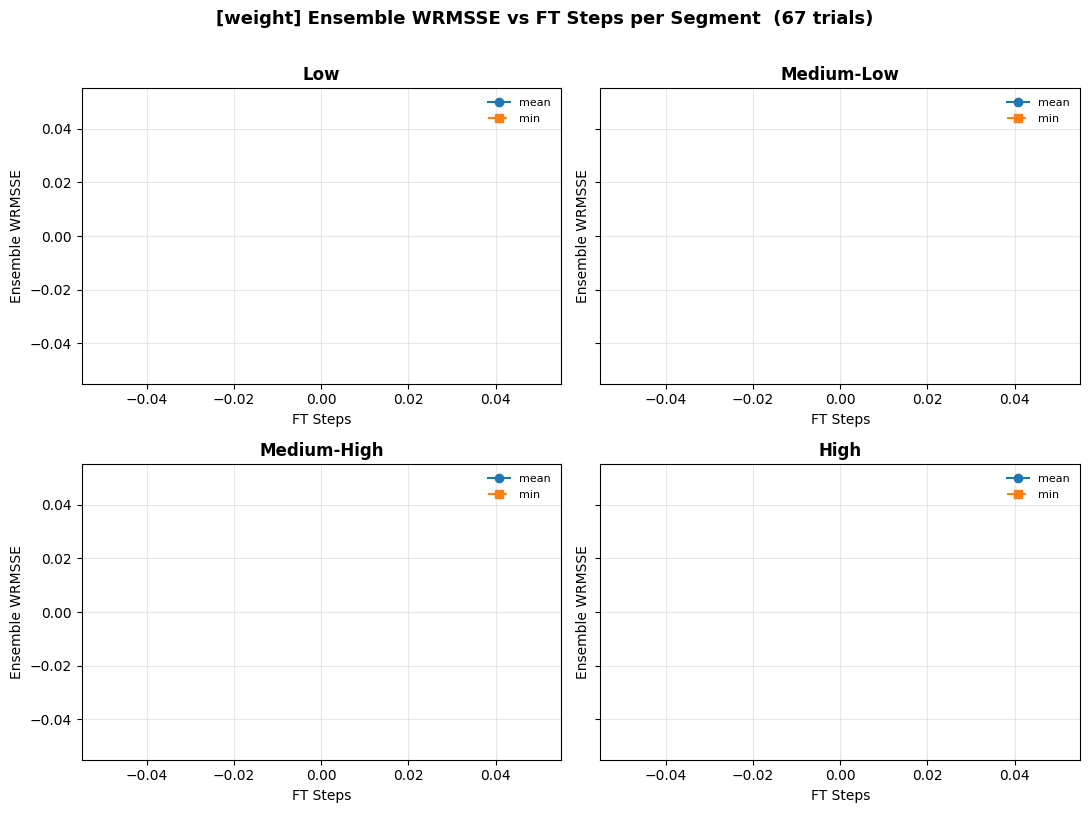

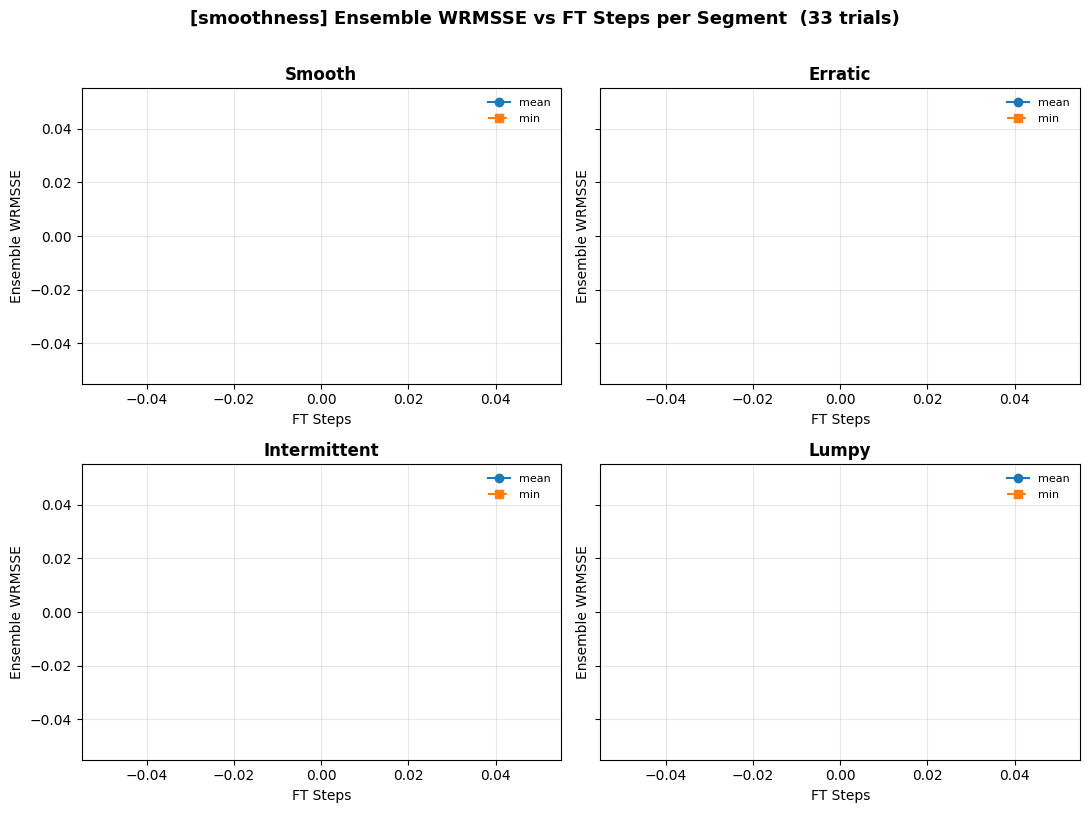

In [ ]:
# ── ft_steps vs WRMSSE — one subplot per segment, split by scheme ─────────────
for seg_cols, seg_names_list in SEG_NAMES_MAP.items():
    scheme = seg_cols.replace("_segs", "")

    if has_scheme:
        sub = df_trials[df_trials[scheme_col] == seg_cols]
    else:
        sub = df_trials

    if sub.empty:
        continue

    n_segs = len(seg_names_list)
    ncols  = min(n_segs, 2)
    nrows  = (n_segs + ncols - 1) // ncols

    fig, axes = plt.subplots(nrows, ncols, figsize=(11, 4 * nrows), sharey=True)
    axes = axes.flatten() if n_segs > 1 else [axes]

    for ax, seg in zip(axes, seg_names_list):
        sk       = _seg_key(scheme, seg)
        step_key = f"params_ft_steps_{sk}"
        if step_key not in sub.columns:
            ax.set_visible(False)
            continue
        grouped = sub.groupby(step_key)["WRMSSE"].agg(["mean", "min"]).reset_index()
        ax.plot(grouped[step_key], grouped["mean"], marker="o", label="mean")
        ax.plot(grouped[step_key], grouped["min"],  marker="s", linestyle="--", label="min")
        ax.set_title(seg, fontweight="bold")
        ax.set_xlabel("FT Steps")
        ax.set_ylabel("Ensemble WRMSSE")
        ax.legend(frameon=False, fontsize=8)
        ax.grid(True, alpha=0.3)

    for ax in axes[n_segs:]:
        ax.set_visible(False)

    fig.suptitle(
        f"[{scheme}] Ensemble WRMSSE vs FT Steps per Segment  ({len(sub)} trials)",
        fontsize=13, fontweight="bold", y=1.01,
    )
    fig.tight_layout()
    plt.show()

In [ ]:
from pathlib import Path

out = Path(f"/mnt/lab/nmwamsojo/results/m5_hpo_ft_ensemble_v6_{CUTOFF_DAY.replace('-', '')}.csv")
out.parent.mkdir(parents=True, exist_ok=True)
df_trials.to_csv(out, index=False)
print(f"Results saved → {out}  ({len(df_trials)} rows)")

Results saved → /mnt/lab/nmwamsojo/results/m5_hpo_ft_ensemble_v6_20160424.csv  (100 rows)
